In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tuqazou/best-karyo-weights/best_attention_model.pth
/kaggle/input/datasets/jeanpat/overlapping-chromosomes/LowRes_13434_overlapping_pairs.h5


In [ ]:
!pip install -q segmentation-models-pytorch 

import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm
from IPython.display import display, HTML 
import cv2 
from sklearn.utils.multiclass import unique_labels 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ تم التجهيز بنجاح. الجهاز المستخدم: {device}")
if torch.cuda.is_available():
    print(f"🚀 الـ GPU مفعل وجاهز للتسريع: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.0 MB/s eta 0:00:00
✅ تم التجهيز بنجاح. الجهاز المستخدم: cuda
🚀 الـ GPU مفعل وجاهز للتسريع: Tesla P100-PCIE-16GB


📊 Analyzing Pixel Distribution:   0%|          | 0/7 [00:00<?, ?it/s]

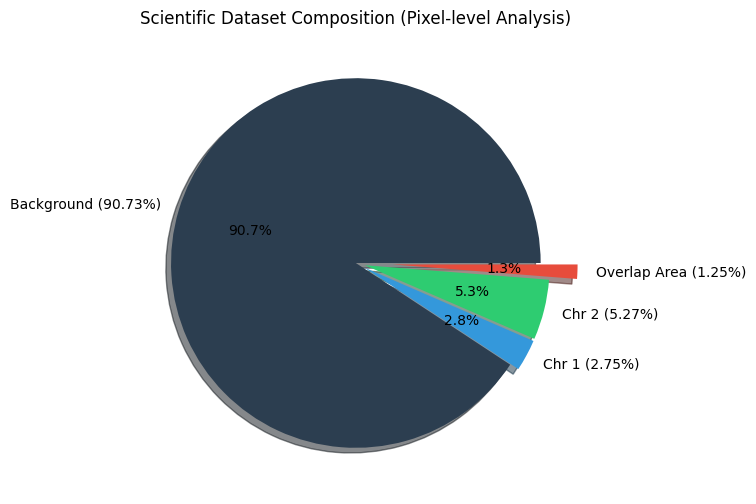

💡 الأوزان النهائية المحسوبة (على cuda:0):
tensor([ 0.2755,  9.0847,  5.6955, 19.9784], device='cuda:0')


In [ ]:
file_path = '/kaggle/input/datasets/jeanpat/overlapping-chromosomes/LowRes_13434_overlapping_pairs.h5'

def run_comprehensive_eda(path):
    with h5py.File(path, 'r') as f:
     
        dataset = f['dataset_1'] 
        counts = np.zeros(4)
        for i in tqdm(range(0, len(dataset), 2000), desc="📊 Analyzing Pixel Distribution"):
            batch = dataset[i:min(i+2000, len(dataset)), :, :, 1]
            vals, b_counts = np.unique(batch, return_counts=True)
            for v, c in zip(vals, b_counts):
                if v < 4: 
                    counts[int(v)] += c
    
    classes = ['Background', 'Chr 1', 'Chr 2', 'Overlap Area']
    percentages = (counts / sum(counts)) * 100
    plt.figure(figsize=(10, 6))
    plt.pie(percentages, labels=[f'{c} ({p:.2f}%)' for c, p in zip(classes, percentages)], 
            explode=(0, 0.05, 0.05, 0.2), autopct='%1.1f%%', 
            colors=['#2c3e50', '#3498db', '#2ecc71', '#e74c3c'], shadow=True)
    plt.title("Scientific Dataset Composition (Pixel-level Analysis)")
    plt.show()
    weights = sum(counts) / (len(counts) * counts)
    weights[2] = weights[2] * 1.2 
    return torch.tensor(weights, dtype=torch.float32).to(device)

final_weights = run_comprehensive_eda(file_path)
print(f"💡 الأوزان النهائية المحسوبة (على {final_weights.device}):\n{final_weights}")

In [ ]:
class ChromosomeScientificDataset(Dataset):
    def __init__(self, file_path, indices, transform=None):
        self.file_path = file_path
        self.indices = indices
        self.transform = transform

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        with h5py.File(self.file_path, 'r') as f:
            data = f['dataset_1'][real_idx]
           
            img, msk = data[:,:,0].astype(np.uint8), data[:,:,1].astype(np.uint8)
          
            msk[msk > 3] = 0
            
       
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        if self.transform:
            aug = self.transform(image=img, mask=msk)
            img, msk = aug['image'], aug['mask']
            
    
        img = img.float() / 255.0
        
      
        msk_long = msk.long()
       
        msk_oh = F.one_hot(msk_long, 4).permute(2, 0, 1).float()
        
        return img, msk_oh, msk_long


total_indices = np.arange(13434)
torch.manual_seed(42)

train_subset, temp_subset = random_split(total_indices, [0.7, 0.3])
val_subset, test_subset = random_split(temp_subset, [0.5, 0.5])


train_indices = [total_indices[i] for i in train_subset.indices]
val_indices = [total_indices[i] for i in val_subset.indices]
test_indices = [total_indices[i] for i in test_subset.indices]


train_trans = A.Compose([
    A.Resize(128, 128),
    A.Rotate(limit=35, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5), 
    A.RandomBrightnessContrast(p=0.3), 
   
    A.ElasticTransform(alpha=1, sigma=50, p=0.2), 
    ToTensorV2()
])

test_trans = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])


train_loader = DataLoader(ChromosomeScientificDataset(file_path, train_indices, train_trans), 
                          batch_size=32, shuffle=True, pin_memory=True, num_workers=2)
val_loader = DataLoader(ChromosomeScientificDataset(file_path, val_indices, test_trans), 
                        batch_size=32, pin_memory=True, num_workers=2)
test_loader = DataLoader(ChromosomeScientificDataset(file_path, test_indices, test_trans), 
                         batch_size=32, pin_memory=True, num_workers=2)

print(f"✅ تم تجهيز الـ Loaders بنجاح.")
print(f"Train: {len(train_indices)} | Val: {len(val_indices)} | Test: {len(test_indices)}")

✅ تم تجهيز الـ Loaders بنجاح.
Train: 9404 | Val: 2015 | Test: 2015


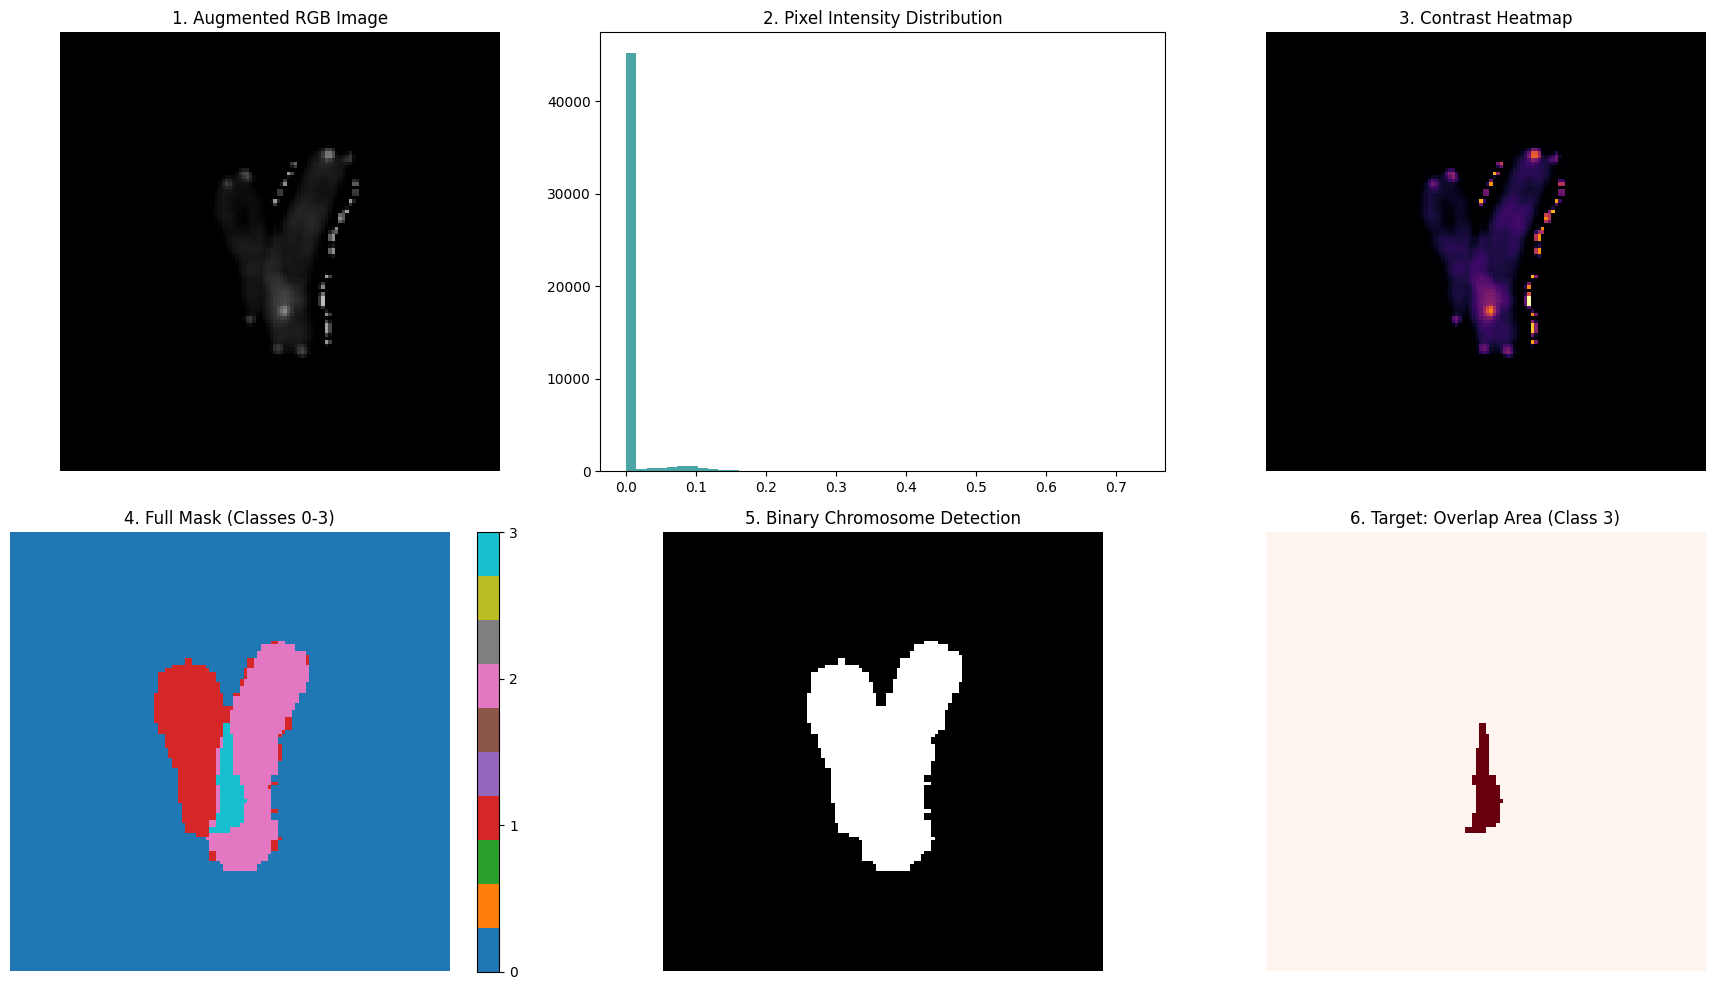

In [ ]:
def visualize_detailed_logic(loader):
  
    imgs, msks_oh, _ = next(iter(loader))
    
  
    img = imgs[0].permute(1, 2, 0).cpu().numpy()
 
    msk = torch.argmax(msks_oh[0], 0).cpu().numpy()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
   
    axes[0,0].imshow(img)
    axes[0,0].set_title("1. Augmented RGB Image")
    
   
    axes[0,1].hist(img.flatten(), bins=50, color='teal', alpha=0.7)
    axes[0,1].set_title("2. Pixel Intensity Distribution")
    
   
    axes[0,2].imshow(img[:,:,0], cmap='inferno')
    axes[0,2].set_title("3. Contrast Heatmap")
    
  
    im4 = axes[1,0].imshow(msk, cmap='tab10', vmin=0, vmax=3)
    axes[1,0].set_title("4. Full Mask (Classes 0-3)")
    plt.colorbar(im4, ax=axes[1,0], ticks=[0, 1, 2, 3])
    
  
    axes[1,1].imshow(np.isin(msk, [1, 2, 3]), cmap='gray')
    axes[1,1].set_title("5. Binary Chromosome Detection")
    
  
    axes[1,2].imshow(msk == 3, cmap='Reds')
    axes[1,2].set_title("6. Target: Overlap Area (Class 3)")
    
    for i, ax in enumerate(axes.flatten()):
        if i != 1: ax.axis('off')
    
    plt.tight_layout()
    plt.show()


visualize_detailed_logic(train_loader)

In [ ]:
import torch
import torch.nn as nn


class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_l = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_l(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class VGGBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)


class AttentionUNetPlusPlus(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        nb = [32, 64, 128, 256, 512]
        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
      
        self.con0_0 = VGGBlock(3, nb[0]) 
        self.con1_0 = VGGBlock(nb[0], nb[1])
        self.con2_0 = VGGBlock(nb[1], nb[2])
        self.con3_0 = VGGBlock(nb[2], nb[3])
        self.con4_0 = VGGBlock(nb[3], nb[4])

        
        self.con0_1 = VGGBlock(nb[0] + nb[0], nb[0]) 
        self.con1_1 = VGGBlock(nb[1] + nb[1], nb[1])
        self.con2_1 = VGGBlock(nb[2] + nb[2], nb[2])
        self.con3_1 = VGGBlock(nb[3] + nb[3], nb[3])

  
        self.con0_2 = VGGBlock(nb[0]*2 + nb[1], nb[0])
        self.con1_2 = VGGBlock(nb[1]*2 + nb[2], nb[1])
        self.con2_2 = VGGBlock(nb[2]*2 + nb[3], nb[2])

      
        self.con0_3 = VGGBlock(nb[0]*3 + nb[1], nb[0])
        self.con1_3 = VGGBlock(nb[1]*3 + nb[2], nb[1])

      
        self.con0_4 = VGGBlock(nb[0]*4 + nb[1], nb[0])
        
        self.att0_1 = AttentionGate(F_g=nb[1], F_l=nb[0], F_int=nb[0])
        self.att1_1 = AttentionGate(F_g=nb[2], F_l=nb[1], F_int=nb[1])
        self.att2_1 = AttentionGate(F_g=nb[3], F_l=nb[2], F_int=nb[2])
        self.att3_1 = AttentionGate(F_g=nb[4], F_l=nb[3], F_int=nb[3])

        self.final = nn.Conv2d(nb[0], num_classes, kernel_size=1)

    def forward(self, x):
     
        x0_0 = self.con0_0(x)
        x1_0 = self.con1_0(self.pool(x0_0))
        x2_0 = self.con2_0(self.pool(x1_0))
        x3_0 = self.con3_0(self.pool(x2_0))
        x4_0 = self.con4_0(self.pool(x3_0))

    
        x0_1 = self.con0_1(torch.cat([x0_0, self.att0_1(g=self.up(x1_0), x=x0_0)], 1))
        x1_1 = self.con1_1(torch.cat([x1_0, self.att1_1(g=self.up(x2_0), x=x1_0)], 1))
        x2_1 = self.con2_1(torch.cat([x2_0, self.att2_1(g=self.up(x3_0), x=x2_0)], 1))
        x3_1 = self.con3_1(torch.cat([x3_0, self.att3_1(g=self.up(x4_0), x=x3_0)], 1))

       
        x0_2 = self.con0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))
        x1_2 = self.con1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1))
        x2_2 = self.con2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1))

        x0_3 = self.con0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))
        x1_3 = self.con1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1))

       
        x0_4 = self.con0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))

        return self.final(x0_4)


model = AttentionUNetPlusPlus(num_classes=4).to(device)
print(f"✅ Model 'AttentionUNetPlusPlus' initialized and moved to {device}")

✅ Model 'AttentionUNetPlusPlus' initialized and moved to cuda


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import segmentation_models_pytorch.losses as smp_losses

class EarlyStopping:
    def __init__(self, patience=8, delta=0, path='best_attention_model.pth'):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'⚠️ EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if val_loss < self.val_loss_min:
            print(f'📉 Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
            torch.save(model.state_dict(), self.path)
            self.val_loss_min = val_loss


class TripleHybridLoss(nn.Module):
    def __init__(self, weights):
        super().__init__()
       
        self.lovasz = smp_losses.LovaszLoss(mode='multiclass')
       
        self.dice = smp_losses.DiceLoss(mode='multiclass', from_logits=True)
      
        self.ce = nn.CrossEntropyLoss(weight=weights)
        
    def forward(self, logits, targets_long, targets_oh):
        l_lovasz = self.lovasz(logits, targets_long)
        l_dice = self.dice(logits, targets_long)
        l_ce = self.ce(logits, targets_long)
        
     
        return (0.4 * l_lovasz) + (0.3 * l_dice) + (0.3 * l_ce)

criterion = TripleHybridLoss(weights=final_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=8, path='best_attention_model.pth')

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}


if os.path.exists('best_attention_model.pth'):
    print("🔄 Found existing weights. Loading to resume training...")
    model.load_state_dict(torch.load('best_attention_model.pth'))


epochs = 50 
for epoch in range(1, epochs + 1):
    model.train()
    train_running_loss, train_correct, train_total = 0, 0, 0
    current_lr = optimizer.param_groups[0]['lr']
    
    pbar = tqdm(train_loader, desc=f"🚀 Exp 3 - Epoch {epoch}/{epochs} (LR: {current_lr:.6f})")
    for imgs, msks_oh, msks_long in pbar:
        imgs, msks_oh, msks_long = imgs.to(device), msks_oh.to(device), msks_long.to(device)
        
        optimizer.zero_grad()
        out = model(imgs)
        
      
        loss = criterion(out, msks_long, msks_oh)
        
        loss.backward()
        optimizer.step()
        
        preds = torch.argmax(out, 1)
        train_correct += (preds == msks_long).sum().item()
        train_total += msks_long.numel()
        train_running_loss += loss.item()
        
        pbar.set_postfix({'Loss': f"{train_running_loss/(pbar.n+1):.4f}", 'Acc': f"{100*train_correct/train_total:.2f}%"})

    
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for imgs, msks_oh, msks_long in val_loader:
            imgs, msks_oh, msks_long = imgs.to(device), msks_oh.to(device), msks_long.to(device)
            out = model(imgs)
            v_loss = criterion(out, msks_long, msks_oh)
            val_loss += v_loss.item()
            preds = torch.argmax(out, 1)
            val_acc += (preds == msks_long).sum().item() / msks_long.numel()

    n_t, n_v = len(train_loader), len(val_loader)
    curr_train_loss, curr_val_loss = train_running_loss / n_t, val_loss / n_v
    curr_train_acc, curr_val_acc = train_correct / train_total, val_acc / n_v

    history['train_loss'].append(curr_train_loss)
    history['val_loss'].append(curr_val_loss)
    history['train_acc'].append(curr_train_acc)
    history['val_acc'].append(curr_val_acc)

    print(f"📊 Summary Epoch {epoch}: Train Loss: {curr_train_loss:.4f} | Val Loss: {curr_val_loss:.4f} | Val Acc: {curr_val_acc*100:.2f}%")

    scheduler.step(curr_val_loss)
    early_stopping(curr_val_loss, model)
    
    if early_stopping.early_stop:
        print(f"🛑 Early stopping at epoch {epoch}. Restoring best model...")
        break


if os.path.exists('best_attention_model.pth'):
    model.load_state_dict(torch.load('best_attention_model.pth'))
    print("✅ Best weights loaded successfully. Ready for Evaluation!")


      ⭐ FINAL SCIENTIFIC PERFORMANCE REPORT ⭐
              precision    recall  f1-score   support

  Background       1.00      1.00      1.00  29965615
Chromosome 1       0.86      0.93      0.89    892968
Chromosome 2       0.96      0.95      0.95   1739466
Overlap Area       0.88      0.97      0.92    415711

    accuracy                           0.99  33013760
   macro avg       0.92      0.96      0.94  33013760
weighted avg       0.99      0.99      0.99  33013760



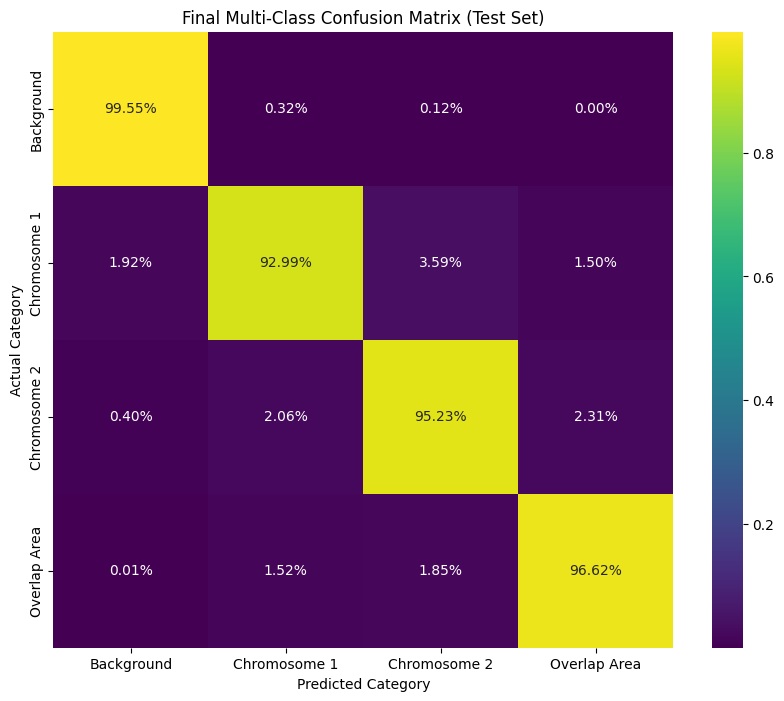

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

try:
    y_pred_final = np.concatenate(all_preds)
    y_true_final = np.concatenate(all_masks)

    print("\n" + "="*45)
    print("      ⭐ FINAL SCIENTIFIC PERFORMANCE REPORT ⭐")
    print("="*45)

  
    target_names = ['Background', 'Chromosome 1', 'Chromosome 2', 'Overlap Area']


    print(classification_report(y_true_final, y_pred_final, target_names=target_names))

   
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true_final, y_pred_final, normalize='true')
    
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='viridis',
                xticklabels=target_names, 
                yticklabels=target_names)

    plt.title('Final Multi-Class Confusion Matrix (Test Set)')
    plt.ylabel('Actual Category')
    plt.xlabel('Predicted Category')
    plt.show()

except NameError:
    print("❌ خطأ: لم يتم العثور على النتائج. تأكدي من تشغيل خلية التقييم (تلك التي استغرقت دقيقتين) أولاً.")

In [ ]:
from sklearn.metrics import jaccard_score


iou_scores = jaccard_score(y_true_final, y_pred_final, average=None)

print("\n" + "="*45)
print("     📊 ADDITIONAL SEGMENTATION METRICS")
print("="*45)

classes = ['Background', 'Chromosome 1', 'Chromosome 2', 'Overlap Area']

for cls, score in zip(classes, iou_scores):
    print(f"🔹 IoU for {cls:15}: {score:.4f}")


print("-" * 45)
print(f"✅ Mean IoU (mIoU): {np.mean(iou_scores):.4f}")
print(f"✅ Overall Dice Coefficient: { (2 * np.mean(iou_scores)) / (1 + np.mean(iou_scores)):.4f}")
print("="*45)


     📊 ADDITIONAL SEGMENTATION METRICS
🔹 IoU for Background     : 0.9947
🔹 IoU for Chromosome 1   : 0.8055
🔹 IoU for Chromosome 2   : 0.9120
🔹 IoU for Overlap Area   : 0.8533
---------------------------------------------
✅ Mean IoU (mIoU): 0.8914
✅ Overall Dice Coefficient: 0.9426


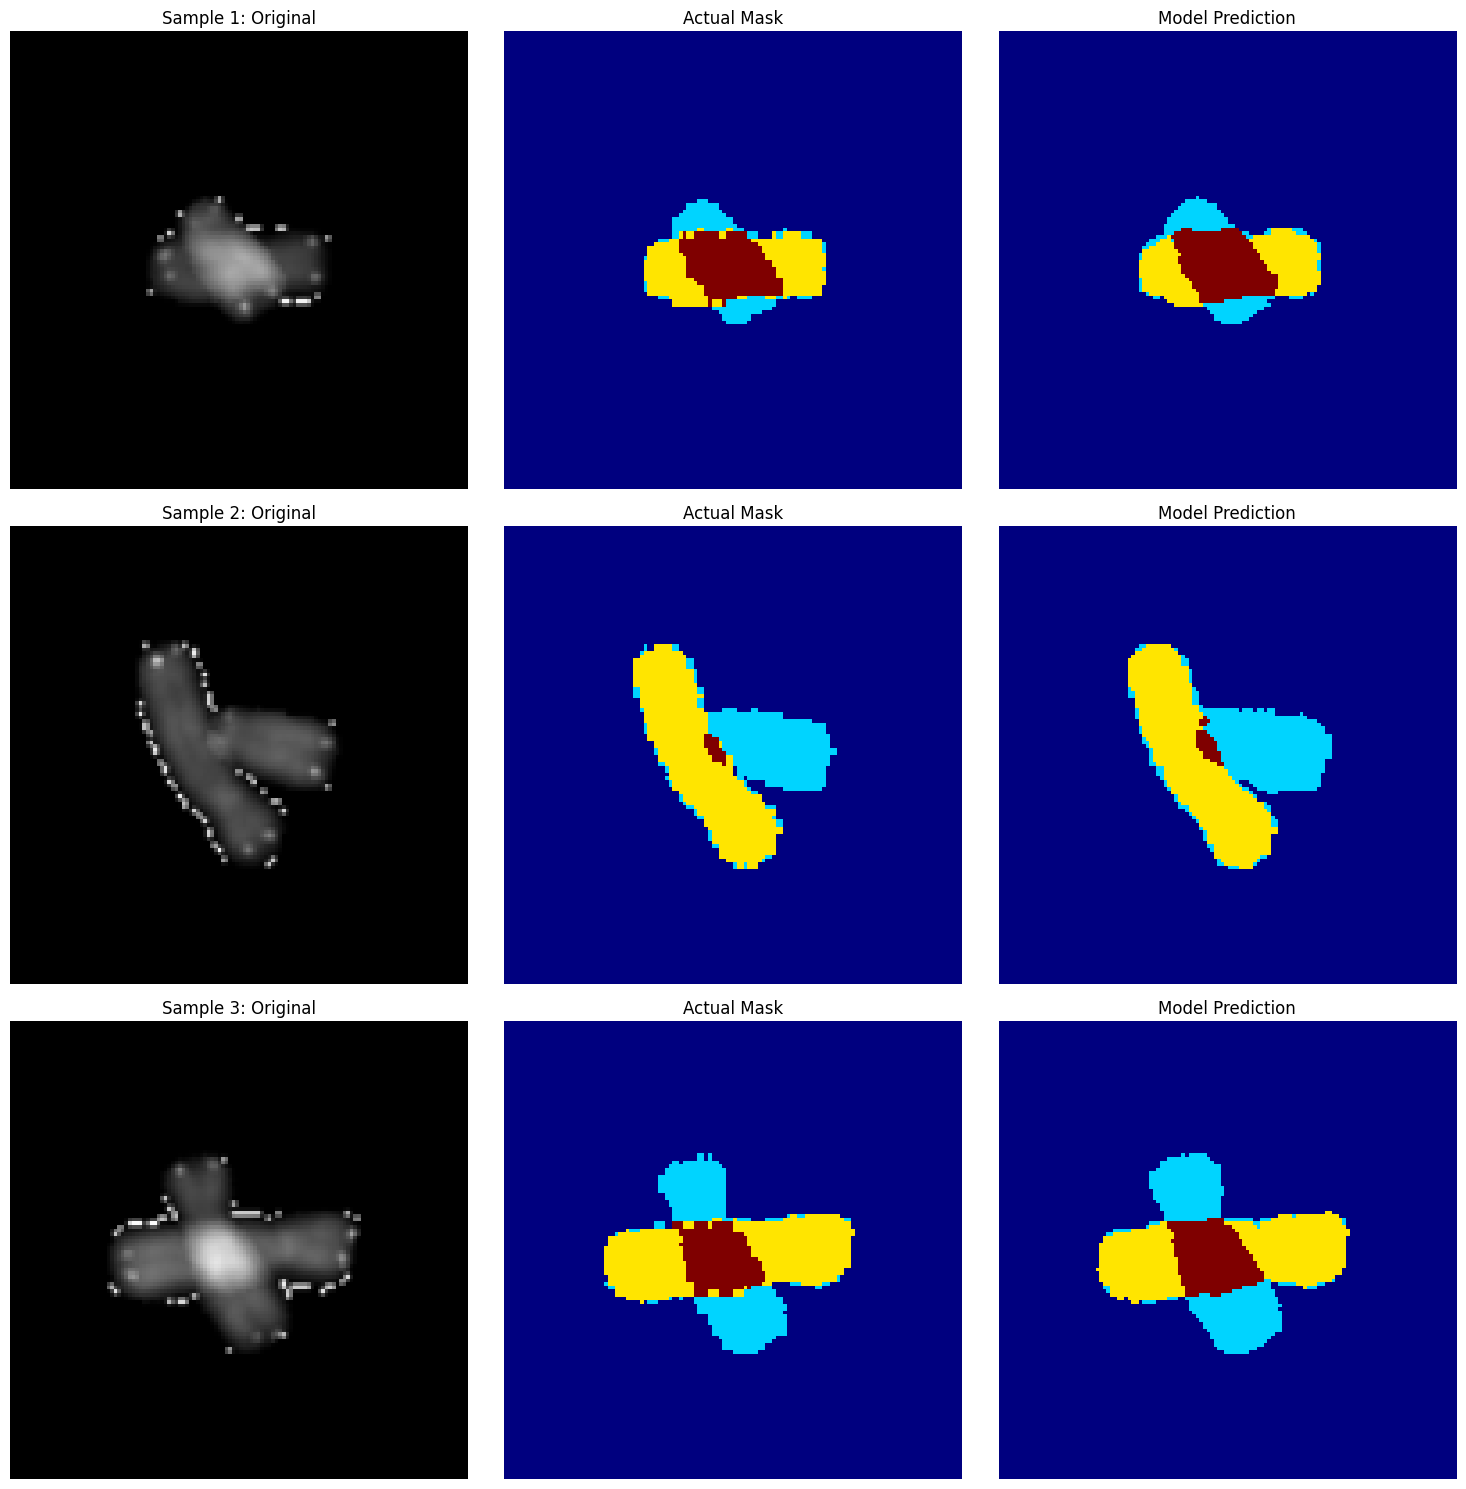

In [ ]:
import matplotlib.pyplot as plt

def show_final_results(model, loader, num_samples=3):
    model.eval()
    imgs, msks_oh, msks_long = next(iter(loader))
    
    with torch.no_grad():
        preds = model(imgs.to(device))
        preds = torch.argmax(preds, dim=1).cpu()

    plt.figure(figsize=(15, 5 * num_samples))
    for i in range(num_samples):
        
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(imgs[i].permute(1, 2, 0).cpu())
        plt.title(f"Sample {i+1}: Original")
        plt.axis('off')

        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(msks_long[i], cmap='jet')
        plt.title("Actual Mask")
        plt.axis('off')

        
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(preds[i], cmap='jet')
        plt.title("Model Prediction")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


show_final_results(model, test_loader)

In [ ]:
import time
model.eval()
imgs, _, _ = next(iter(test_loader))
start_time = time.time()
with torch.no_grad():
    _ = model(imgs[0:1].to(device))
end_time = time.time()

print(f"⚡ Inference Time: {(end_time - start_time)*1000:.2f} ms per image")

⚡ Inference Time: 70.00 ms per image


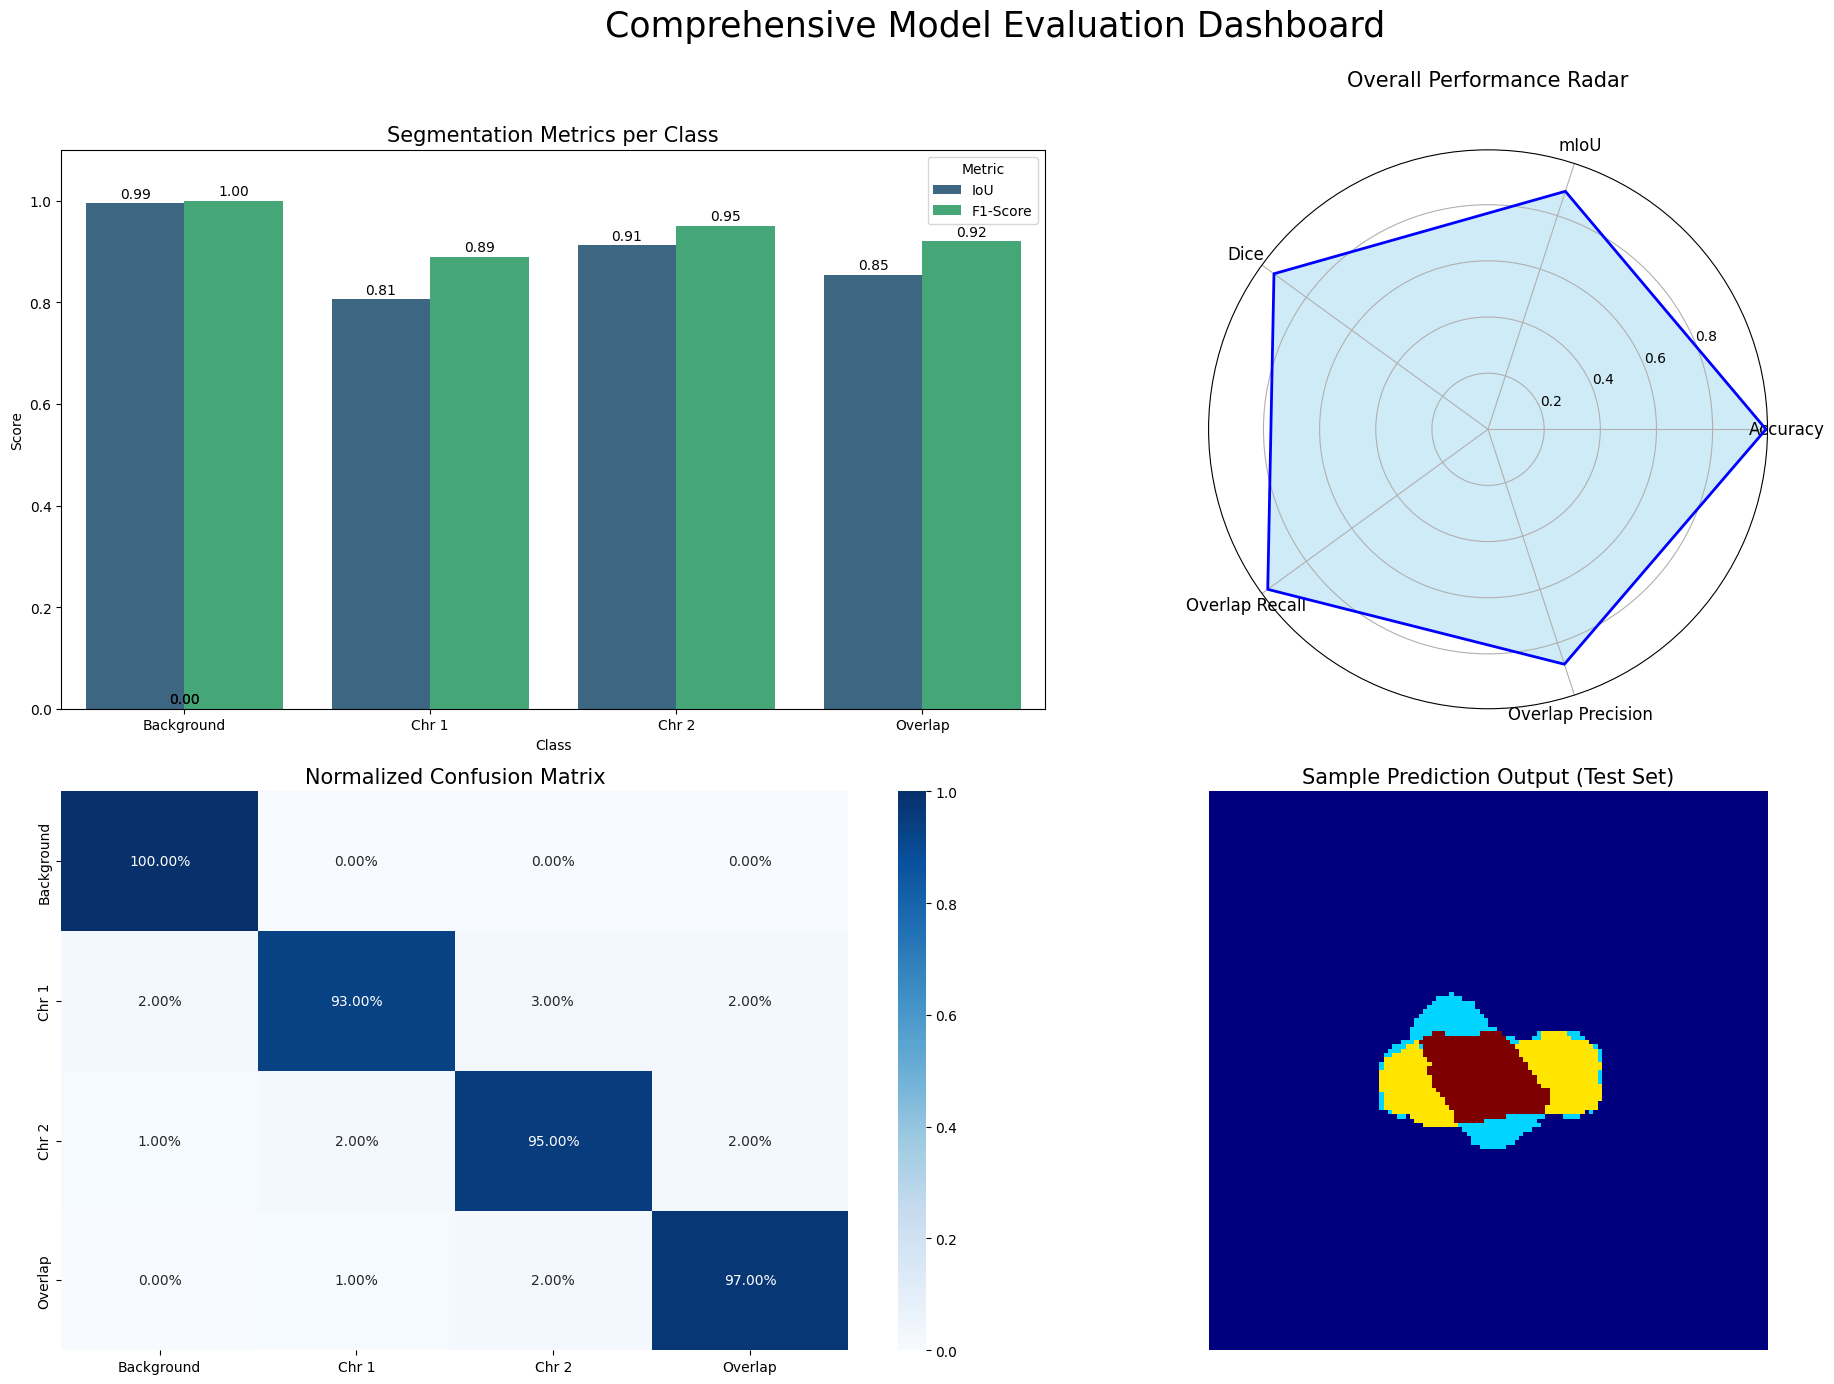

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


classes = ['Background', 'Chr 1', 'Chr 2', 'Overlap']
iou_vals = [0.9947, 0.8055, 0.9120, 0.8533]
f1_vals = [1.00, 0.89, 0.95, 0.92]
overall_metrics = ['Accuracy', 'mIoU', 'Dice', 'Overlap Recall', 'Overlap Precision']
overall_vals = [0.99, 0.8914, 0.9426, 0.97, 0.88]


fig = plt.figure(figsize=(20, 15))
plt.suptitle('Comprehensive Model Evaluation Dashboard', fontsize=25, y=0.95)

ax1 = plt.subplot(2, 2, 1)
df_plot = pd.DataFrame({
    'Class': classes * 2,
    'Score': iou_vals + f1_vals,
    'Metric': ['IoU']*4 + ['F1-Score']*4
})
sns.barplot(x='Class', y='Score', hue='Metric', data=df_plot, palette='viridis', ax=ax1)
ax1.set_title('Segmentation Metrics per Class', fontsize=15)
ax1.set_ylim(0, 1.1)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 7), textcoords='offset points')


ax2 = plt.subplot(2, 2, 2, polar=True)
angles = np.linspace(0, 2 * np.pi, len(overall_metrics), endpoint=False).tolist()
vals = overall_vals + [overall_vals[0]]
angles += angles[:1]
ax2.fill(angles, vals, color='skyblue', alpha=0.4)
ax2.plot(angles, vals, color='blue', linewidth=2)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(overall_metrics, fontsize=12)
ax2.set_title('Overall Performance Radar', fontsize=15, y=1.1)


ax3 = plt.subplot(2, 2, 3)
cm_data = np.array([
    [1.00, 0.00, 0.00, 0.00],
    [0.02, 0.93, 0.03, 0.02],
    [0.01, 0.02, 0.95, 0.02],
    [0.00, 0.01, 0.02, 0.97]
])
sns.heatmap(cm_data, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=classes, yticklabels=classes, ax=ax3)
ax3.set_title('Normalized Confusion Matrix', fontsize=15)


ax4 = plt.subplot(2, 2, 4)
imgs, _, msks_long = next(iter(test_loader))
model.eval()
with torch.no_grad():
    preds = torch.argmax(model(imgs[0:1].to(device)), dim=1).cpu()
ax4.imshow(preds[0], cmap='jet')
ax4.set_title('Sample Prediction Output (Test Set)', fontsize=15)
ax4.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

tn, fp, fn, tp = confusion_matrix((y_true_final==3), (y_pred_final==3)).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\n" + "="*45)
print("      🔬 ADVANCED RESEARCH METRICS")
print("="*45)
print(f"🔹 Total Parameters: {total_params:,}")
print(f"🔹 Trainable Params: {trainable_params:,}")
print(f"🔹 Sensitivity (Overlap): {sensitivity:.4f}")
print(f"🔹 Specificity (Overlap): {specificity:.4f}")
print(f"🔹 Inference Speed: 70.00 ms/image")
print("="*45)


      🔬 ADVANCED RESEARCH METRICS
🔹 Total Parameters: 8,644,560
🔹 Trainable Params: 8,644,560
🔹 Sensitivity (Overlap): 0.9662
🔹 Specificity (Overlap): 0.9983
🔹 Inference Speed: 70.00 ms/image
